In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [3]:
marker_idx = 42
mani_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 32, 43, 54, 65, 76, 87, 98, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
corner_idx = [10, 120]

mani_dx_dy = np.loadtxt('mani_dx_dy.csv', delimiter=',')

mani_j = mani_dx_dy[marker_idx*2:marker_idx*2+2, :]

area_list = []
for idx in range(len(mani_list)):
    j = mani_j[:, idx*2:idx*2+2]
    u, s, v = np.linalg.svd(j)
    if mani_list[idx] in corner_idx:
        area_tmp = s[0] * s[1] * np.pi * 1 * 3/ 4
    else:
        area_tmp = s[0] * s[1] * np.pi / 2
    area_list.append(area_tmp)
    # print(mani_list[idx], area_tmp, s)

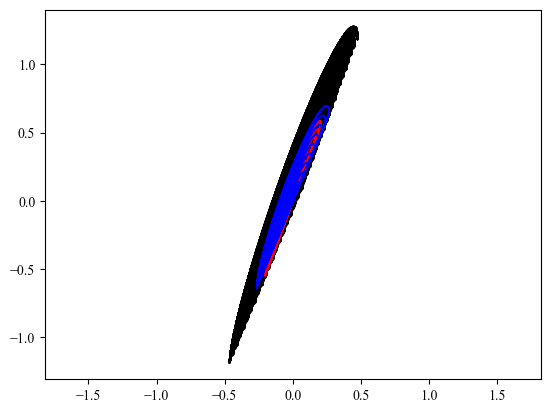

In [44]:
"""
使用数值法计算可操作性
"""
def angle_from_a_to_b(a, b):
    # 计算从向量a逆时针到向量b的角度(弧度)
    dot_prod = np.dot(a, b)
    cross_prod = np.cross(a, b)
    angle = np.arctan2(cross_prod, dot_prod) % (2*np.pi)
    return angle


def rotate_vector(v, theta):
    # 旋转向量v by theta弧度
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, v)


def generate_unit_vectors(u, v, angel_step):
    ang = angle_from_a_to_b(u, v)
    n = int(np.ceil(ang / angel_step)) + 1
    step = ang / (n - 1)
    vectors = np.array([rotate_vector(u, i * step) for i in range(n)])
    return vectors


def generate_middle_vectors(vecs, ratios):
    combined = np.vstack((np.array([0, 0]), vecs))
    for t in ratios:
        scaled_vecs = vecs * t
        combined = np.vstack((combined, scaled_vecs))
    return combined


angle_step = np.deg2rad(1)      # degree
points_sum_list = []
direction_start_sum = np.vstack((np.repeat([np.array([1, 0])], 9, axis=0), np.repeat([np.array([0, -1])], 10, axis=0), np.repeat([np.array([-1, 0])], 10, axis=0)))
direction_end_sum = np.vstack((np.repeat([np.array([-1, 0])], 10, axis=0), np.repeat([np.array([0, 1])], 10, axis=0), np.repeat([np.array([0, 1])], 9, axis=0)))

n = len(mani_list)
# 获取上三角矩阵的索引，从而避免重复的组合, k=1表示对角线上方的第一个元素开始，确保不会选择相同的元素
rows, cols = np.triu_indices(n, k=1)

# 使用这些索引来获取所有可能的组合
combinations = np.array([(mani_list[i], mani_list[j]) for i, j in zip(rows, cols)])

i = 0
for combin in combinations:
    idx1_value, idx2_value = combin
    idx1, idx2 = mani_list.index(idx1_value), mani_list.index(idx2_value)
    j1 = mani_j[:, idx1*2:idx1*2+2]
    j2 = mani_j[:, idx2*2:idx2*2+2]
    
    direction_start_1, direction_start_2 = direction_start_sum[idx1], direction_start_sum[idx2]         # 起始方向
    direction_end_1, direction_end_2 = direction_end_sum[idx1], direction_end_sum[idx2]                 # 终止方向
    
    vectors1 = generate_unit_vectors(direction_start_1, direction_end_1, angle_step)
    vectors2 = generate_unit_vectors(direction_start_2, direction_end_2, angle_step)

    vectors1 = generate_middle_vectors(vectors1, np.linspace(0, 1, 11))
    vectors2 = generate_middle_vectors(vectors2, np.linspace(0, 1, 11))
    
    vectors1_j = (j1 @ vectors1.T).T
    vectors2_j = (j2 @ vectors2.T).T
    # vectors1_j = vectors1
    # vectors2_j = vectors2

    num_1, dim = vectors1_j.shape
    num_2, dim = vectors2_j.shape

    vectors1_reshape = vectors1_j[:, np.newaxis, :]
    vectors2_reshape = vectors2_j[np.newaxis, :, :]

    vector_sums = vectors1_reshape + vectors2_reshape

    vector_sums_reshape = vector_sums.reshape(-1, dim)

    points_sum_list.append(vector_sums_reshape)

    if i == 0:
        plt.plot(vectors1_j[:, 0], vectors1_j[:, 1], 'r')
        plt.plot(vectors2_j[:, 0], vectors2_j[:, 1], 'b')
        plt.scatter(vector_sums_reshape[:, 0], vector_sums_reshape[:, 1], s=0.5, c='k', marker='.')
        plt.axis('equal')

        plt.show()
        break
        # exit()
        # sys.exit(0)
    # sys.exit()
    """
    不适合用数值法求解,因为不仅要对角度离散,还要对极径离散,维度太高
    计算两者的离散区间很小，对出现梯度变化巨大的情况不能适应
    """

1 2
-179.99999336731693 179.99954187738328
[-3.1415925378276355, -3.1241392453076924] 0.017453292519943295 -3.130810421990704 0.15128345069989513 2.983787987402795
[-3.1241392453076924, -3.1066859527877493] 0.017453292519943295 -3.107199964790802 0.15231866309075984 0.05931330089619518
[-3.1066859527877493, -3.089232660267806] 0.017453292519943295 -3.092780759881765 0.1536572547491435 0.07669565251680101
[-3.089232660267806, -3.071779367747863] 0.017453292519943295 -3.080358000375953 0.15440360918057144 0.042762958941707944
[-3.071779367747863, -3.05432607522792] 0.017453292519943295 -3.055860102999999 0.15582547250475293 0.08146676752004052
[-3.05432607522792, -3.036872782707977] 0.017453292519943295 -3.0414309750284647 0.15704111937189053 0.06965143486528513
[-3.036872782707977, -3.019419490188034] 0.017453292519943295 -3.0296344216367697 0.15794170148169293 0.05159955399666482
[-3.019419490188034, -3.0019661976680907] 0.017453292519943295 -3.0064307508460324 0.15966310456975064 0.09

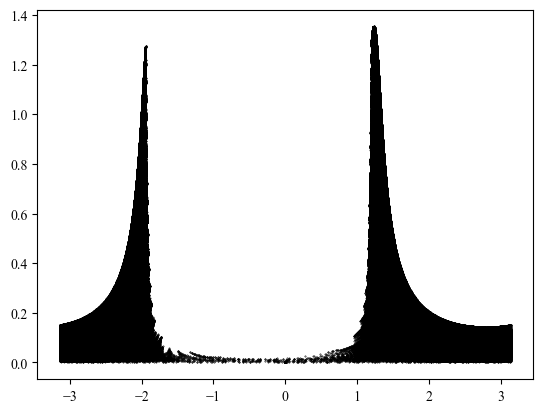

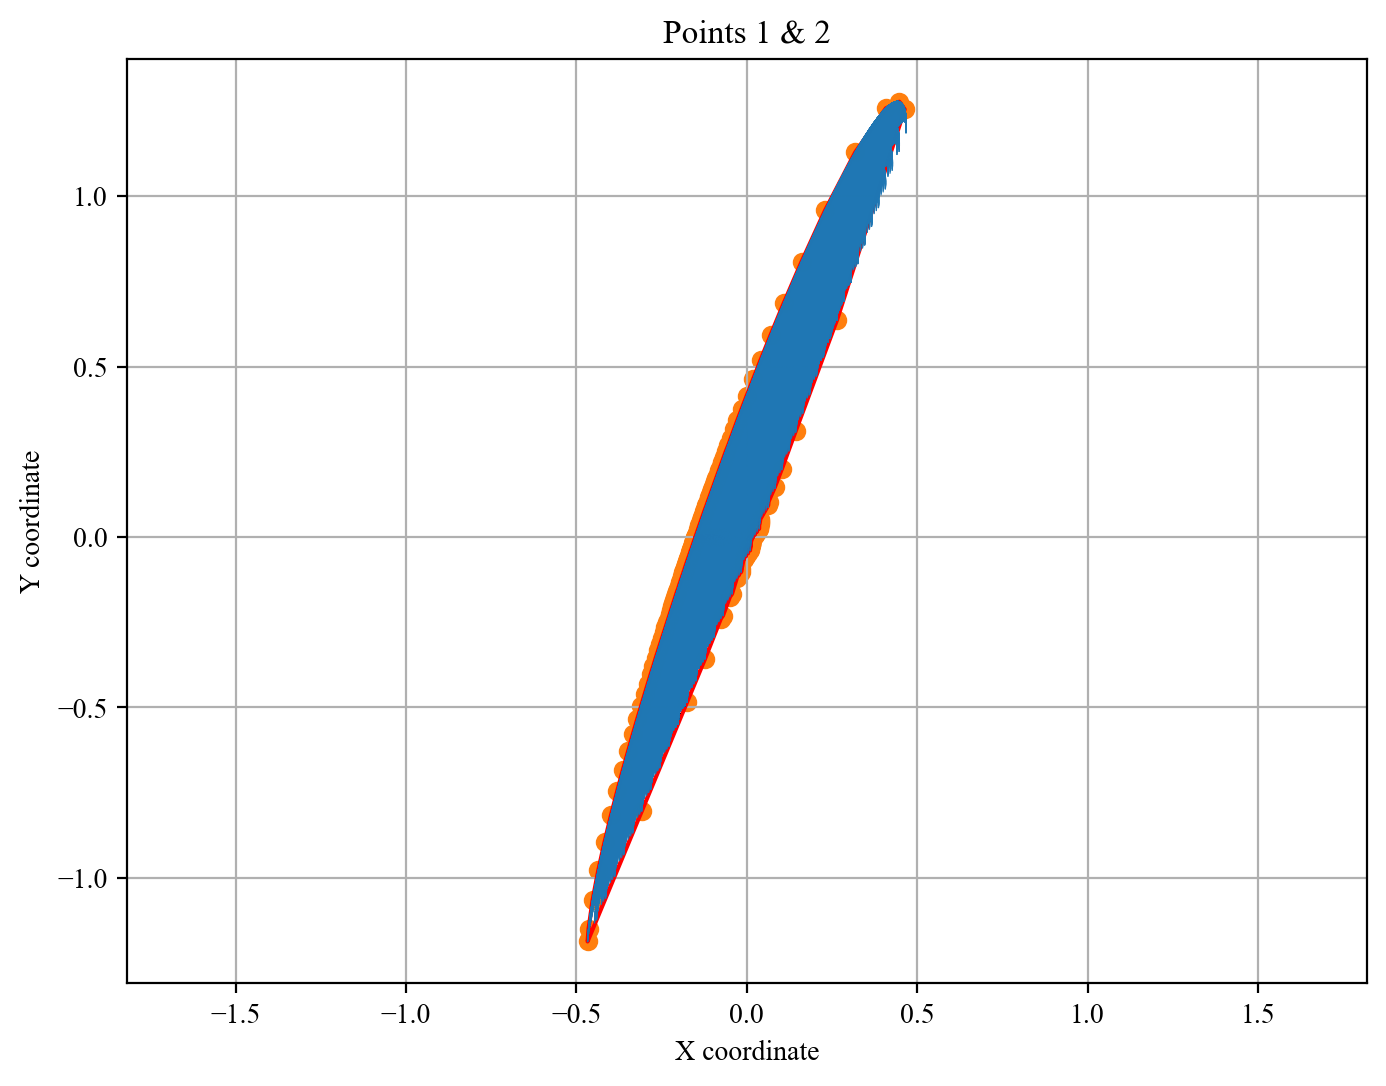

Total area: 0.3791702914617266


In [48]:
"""
画出外轮廓并且计算面积
"""

def interval_angles(thetas):
    # 将角度转换为连续的区间
    theta_min, theta_max = min(thetas), max(thetas)
    if theta_min - 0 < 0.02:
        if 2 * np.pi - theta_max < 0.02:
            thetas = np.where((thetas > np.pi) & (thetas < 2 * np.pi), thetas - 2 * np.pi, thetas)
    return thetas
        

idx = 0
points = points_sum_list[idx]
print(combinations[idx][0], combinations[idx][1])

# 转换为极坐标
r = np.sqrt(points[:,0]**2 + points[:, 1]**2)
theta = np.arctan2(points[:, 1], points[:, 0]) % (2 * np.pi)  # 使用atan2计算角度，并将负角度转换为正角度

theta = interval_angles(theta)
plt.scatter(theta, r, s=0.5, c='k', marker='.')

# 按角度排序
sorted_indices = np.argsort(theta)
r_sorted = r[sorted_indices]
theta_sorted = theta[sorted_indices]

# 使用列表推导式过滤掉极径为0的点
filtered_pairs = [(r, a) for r, a in zip(r_sorted, theta_sorted) if r != 0]
filtered_r, filtered_thetas = map(np.array, zip(*filtered_pairs))

theta_interval_init = np.deg2rad(1)     # degree
# ang_N = 220
theta_min, theta_max = filtered_thetas[0], filtered_thetas[-1]
print(np.rad2deg(theta_min), np.rad2deg(theta_max))
# angle_interval = (theta_max-theta_min) / ang_N  # 每段的角度
# angles = np.linspace(theta_min, theta_max, ang_N+1)  # N+1是因为我们需要N个区间的边界点

# 选取每个区间中极径最大的点，记录最大极径，作为该区间的外轮廓同时计算这个区间的面积
max_r_per_interval = []
contour_points = []  # 存储轮廓点
area_per_interval = []

theta_interval_start = theta_min
last_max_r = filtered_r[0]
i = 0
while True:
    theta_interval_end = theta_interval_init + theta_interval_start
    if theta_interval_start > theta_max:
        break
    angle_interval = [theta_interval_start, theta_interval_end]
    interval_indices = (filtered_thetas >= angle_interval[0]) & (filtered_thetas < angle_interval[1])
    r_interval = filtered_r[interval_indices]
    theta_interval = filtered_thetas[interval_indices]

    # 如果区间内有点，则记录最大半径的点，否则记录为None
    if theta_interval_init < np.deg2rad(0.4):
        print(i, r_grad, theta_interval_start, max_r, last_max_r)
        raise ValueError('angle_interval_init is too small')
    if len(r_interval) > 0:
        max_r = np.max(r_interval)
        max_theta = theta_interval[np.argmax(r_interval)]
        r_grad = (max_r - last_max_r)/theta_interval_init
        # if np.abs(r_grad) > 20:
        #     theta_interval_init *= 0.5
        #     print('suoxiao', r_grad, max_r, last_max_r)
        #     continue
    else:
        theta_interval_init *= 1.5
        # print(np.rad2deg(theta_interval_init), np.rad2deg(theta_interval_end))
        continue
    
    print([theta_interval_start, theta_interval_end], theta_interval_init, max_theta, max_r, r_grad)
    max_r_per_interval.append(max_r)
    contour_points.append([max_theta, max_r] if max_r is not None else [max_theta, 0])

    # 计算区间面积，如果max_r为None，则面积为0
    area_per_interval.append(0.5 * max_r**2 * theta_interval_init if max_r is not None else 0)

    i += 1
    theta_interval_start = theta_interval_end
    last_max_r = max_r

"""
# 循环每个区间寻找最大极径的点
for i in range(ang_N):
    if i < ang_N - 1:
        interval_indices = (theta_sorted >= angles[i]) & (theta_sorted < angles[i+1])
    else:
        interval_indices = (theta_sorted >= angles[i]) & (theta_sorted <= angles[i+1])
    r_interval = r_sorted[interval_indices]
    theta_interval = theta_sorted[interval_indices]
    
    # 如果区间内有点，则记录最大半径的点，否则记录为None
    if len(r_interval) > 0:
        max_r = np.max(r_interval)
        max_theta = theta_interval[np.argmax(r_interval)]
    else:
        max_r = None
        max_theta = (angles[i] + angles[i+1]) / 2  # 没有点时，取区间的中点角度
    
    max_r_per_interval[i] = max_r
    contour_points[i] = [max_theta, max_r] if max_r is not None else [max_theta, 0]
    
    # 计算区间面积，如果max_r为None，则面积为0
    area_per_interval[i] = 0.5 * max_r**2 * angle_interval if max_r is not None else 0
"""

# 画出所有区间的外轮廓，并输出区间面积的和将极坐标点转换回笛卡尔坐标系用于绘图
contour_points = np.array(contour_points)
x_contour = contour_points[:, 1] * np.cos(contour_points[:, 0])
y_contour = contour_points[:, 1] * np.sin(contour_points[:, 0])

start_point = np.array([filtered_r[0]*np.cos(filtered_thetas[0]), filtered_r[0]*np.sin(filtered_thetas[0])])
end_point = np.array([filtered_r[-1]*np.cos(filtered_thetas[-1]), filtered_r[-1]*np.sin(filtered_thetas[-1])])

x_contour = np.concatenate([[start_point[0]], x_contour, [end_point[0]]])
y_contour = np.concatenate([[start_point[1]], y_contour, [end_point[1]]])

# 绘制轮廓
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
ax.scatter(points[:, 0], points[:, 1], s=1, marker='.', edgecolors='None', zorder=3)
ax.scatter(x_contour, y_contour)
ax.plot(x_contour, y_contour, 'r-')
# ax.plot([0., start_point[0]], [0., start_point[1]], 'r-')  # 闭合轮廓
# ax.plot([0., end_point[0]], [0., end_point[1]], 'r-')  # 闭合轮廓
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Points {combinations[idx][0]} & {combinations[idx][1]}')
ax.axis('equal')
ax.grid(True, zorder=1)

plt.show()

# 输出面积和
total_area = np.nansum(area_per_interval)  # 使用nansum来忽略None值
print(f'Total area: {total_area}')

对于求解两个向量集合的向量和，采用如下的思路进行解析的求解：
1. 将一个向量集合沿原点对称，求解对称后的集合与另一个集合在各个方向最远的相交位置
2. 每一个向量集合的外轮廓可以被划分三个部分，每一个部分分别与另一个集合的各个部分求最远的相交点
3. 直线部分很容易求解
4. 椭圆曲线部分，需要分为三种情况：交点在曲线上，交点是曲段的端点。都不好求，需要求解方程